## DA6401W - Assignment 1 Solutions


### Question 1:  Implement Logistic Regression from Scratch for Spam Classification

In [ ]:
# @title
import numpy as np
import pandas as pd
import glob
import re
import os
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress overflow warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

data = []
label = []

for file in glob.glob(os.path.join("Spam","*.txt")):
    l = 'Spam'
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        s = f.read()
        data.append(s)
        label.append(l)

for file in glob.glob(os.path.join("Ham","*.txt")):
    l = 'Ham'
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        s = f.read()
        data.append(s)
        label.append(l)


label_encoding = {'Spam': 1,'Ham': 0}
label_mapped = [label_encoding[i] for i in label] # Mapping "Spam" to 1 and "Non Spam(Ham)" to 0

Data = pd.DataFrame(data, columns=['email'])
print(Data.head()) # Printing the first 5 rows of the dataframe
print()
print('Contents of Sample email before preprocessing:')
print(Data['email'][0]) # Printing sample email before preprocessing
print()

# To reduce all the elements to lower case
Data['email'] = Data['email'].str.lower()

# To remove puntuations
Data['email'] = Data['email'].apply(lambda x: re.sub(r"[^\w\s]", "", x))

# To remove special characters
Data['email'] = Data['email'].apply(lambda x: re.sub(r"[@#\$%^&*\(\)\\/\+-_=\[\]\{\}<>]", "", x))

# To remove Number
Data['email'] = Data['email'].apply(lambda x: re.sub(r'\d+', '', x))

# Remove newline characters (\n)
Data['email'] = Data['email'].apply(lambda x: x.replace('\n', ' '))

# Remove extra spaces
Data['email'] = Data['email'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Applying Lemmatization
l = WordNetLemmatizer()
Data['email'] = Data['email'].apply(lambda x: " ".join(l.lemmatize(word, "v") for word in x.split()))

# Stop words set from nltk
stop_words = set(stopwords.words('english'))

# Function to remove stop words
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

Data['email'] = Data['email'].apply(remove_stopwords)

print('Contents of Sample email after preprocessing:')
print(Data['email'][0]) # Printing sample email after preprocessing
print()

data = list(Data['email'])
text2vec = CountVectorizer(min_df = 0.005) # To be present in a minimum of approx 100 documents to be considered in corpus

X_train, X_test, Y_train, Y_test = train_test_split(data, label_mapped, test_size=0.2, random_state=42, stratify=label_mapped)
# Results in 80% training data, 20% test data

x_train = text2vec.fit_transform(X_train)
x_test = text2vec.transform(X_test)

class LOGisticRegression:
    def __init__(self, l_rate= 0.1, epoch= 1000):
        self.l_rate = l_rate
        self.epoch = epoch
        self.w = None
        self.bias = None

    def sigmoid(self, x):
        return 1/(1 + np.exp(-x))

    def fit(self, X, Y):
        X = X.toarray()
        n_samples = X.shape[0]
        n_features = X.shape[1]
        self.w = np.zeros(n_features)
        self.bias = 0

        for i in range(self.epoch):
            z = np.dot(X, self.w) + self.bias
            y_pred = self.sigmoid(z)

            dw = (1/n_samples) * np.dot(np.transpose(X),(y_pred-Y))
            db = (1/n_samples) * np.sum(y_pred - Y)

            self.w -= self.l_rate * dw
            self.bias -= self.l_rate * db



    def predict(self, X):
        z = np.dot(X.toarray(), self.w)
        y= self.sigmoid(z)
        return [1 if i > 0.5 else 0 for i in y]

    def getWeights(self):
        return self.w


M = LOGisticRegression() # Creating an object of the class
M.fit(x_train, Y_train) # fitting the model

Y = M.predict(x_train)
# Accuracy of Train data
print("Accuracy on Train data: ",sum(x == y for x,y in zip(Y, Y_train))/ len(Y))
print()

# Accuracy on Test data
Y_test_pred = M.predict(x_test)
print("Accuracy on Test data:", sum(x == y for x,y in zip(Y_test_pred, Y_test))/ len(Y_test))
print()

# Train data
confusion_matrix = metrics.confusion_matrix(Y_train, Y)
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.tight_layout()
plt.xlabel("True label")
plt.ylabel("Predicted label")
plt.show()

# Test data
confusion_matrix = metrics.confusion_matrix(Y_test, Y_test_pred)
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.tight_layout()
plt.xlabel("True label")
plt.ylabel("Predicted label")
plt.show()

W = M.getWeights()

with open("Weights.txt",'w') as f:
    for w in W:
        f.write(f"{w}\n")


import pickle
with open('trained_model.pkl','wb') as f:
    pickle.dump({'weights':M.getWeights(), 'vectorizer': text2vec}, f)




### Dataset:

For Spam Classification task, two datasets Enron Spam and Ling-Spam are merged to form
one single dataset. These datasets are obtained from Natural Language Processing Group
Department of Informatics - Athens University of Economics and Business.  

Enrom Spam dataset is featured in the paper  “ V. Metsis, I. Androutsopoulos and G.
Paliouras, "Spam Filtering with Naive Bayes - Which Naive Bayes?". Proceedings of the 3rd
Conference on Email and Anti-Spam (CEAS 2006), Mountain View, CA, USA, 2006”.  

Ling-Spam dataset is featured in the paper “I. Androutsopoulos, J. Koutsias, K.V. Chandrinos,
George Paliouras, and C.D. Spyropoulos, "An Evaluation of Naive Bayesian Anti-Spam
Filtering". In Potamias, G., Moustakis, V. and van Someren, M. (Eds.), Proceedings of the
Workshop on Machine Learning in the New Information Age, 11th European Conference on
Machine Learning (ECML 2000), Barcelona, Spain, pp. 9-17, 2000”.

In both the datasets each message is in a separate text file To prepare the merged dataset,
the files were segregated into two folders: Spam and Ham. In Enron Spam dataset all the
spam messages have the word “spam” in the filename and in Ling-Spam files whose names
have the form spmsg*.txt are spam messages. These spam messages were moved into the
Spam folder, while non-spam messages were placed in the Ham folder.  

The merged dataset contains a total of 9,495 spam messages and 14,650 ham messages.

 *The model achieves a training accuracy of 97.39% and a testing accuracy of 97% on the dataset.*

 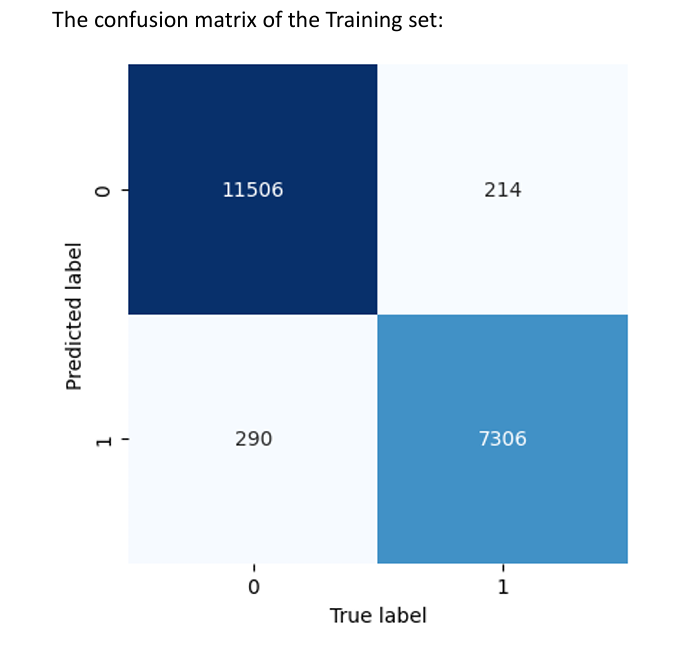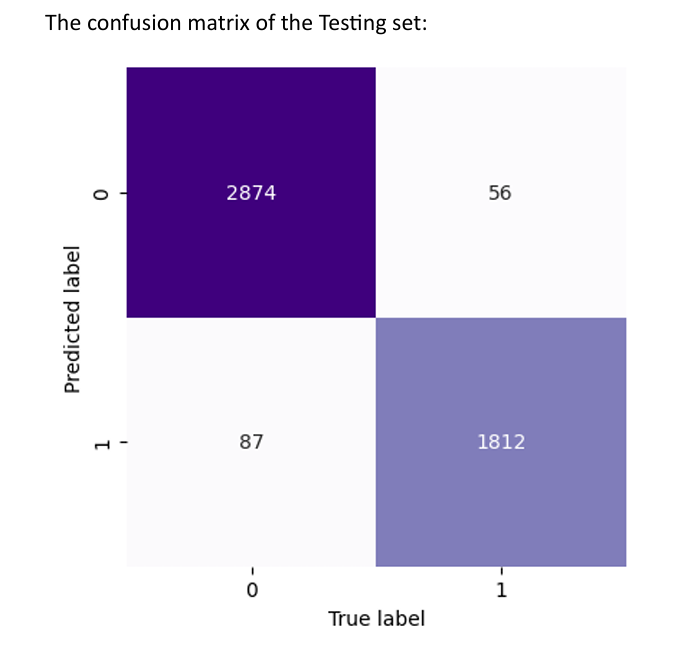

 The Model when tested on SMS SPAM Dataset, it achieved test accuracy of approx 70%.

The model’s performance would vary on the test data due to the data shift i.e., the difference
between training and operational data distribution.

The issue is studied in depth in the
following publication:
Jáñez-Martino, F., Alaiz-Rodríguez, R., González-Castro, V. et al. A review of spam email
detection: analysis of spammer strategies and the dataset shift problem. Artif Intell Rev 56,
1145–1173 (2023). https://doi.org/10.1007/s10462-022-10195-4

### Question 2: Let X = {x1,x2,x3}. Two discrete probability distributions P and Q over X are given as P =[0.5, 0.3, 0.2], Q = [0.4, 0.4, 0.2].

• Compute the cross-entropy H(P,Q).

• Compute the Kullback–Leibler divergence DKL(P∥Q).

• Compute the entropy H(P).

• Derive the relationship between Cross-entropy and KL divergence.

#### Solution:
​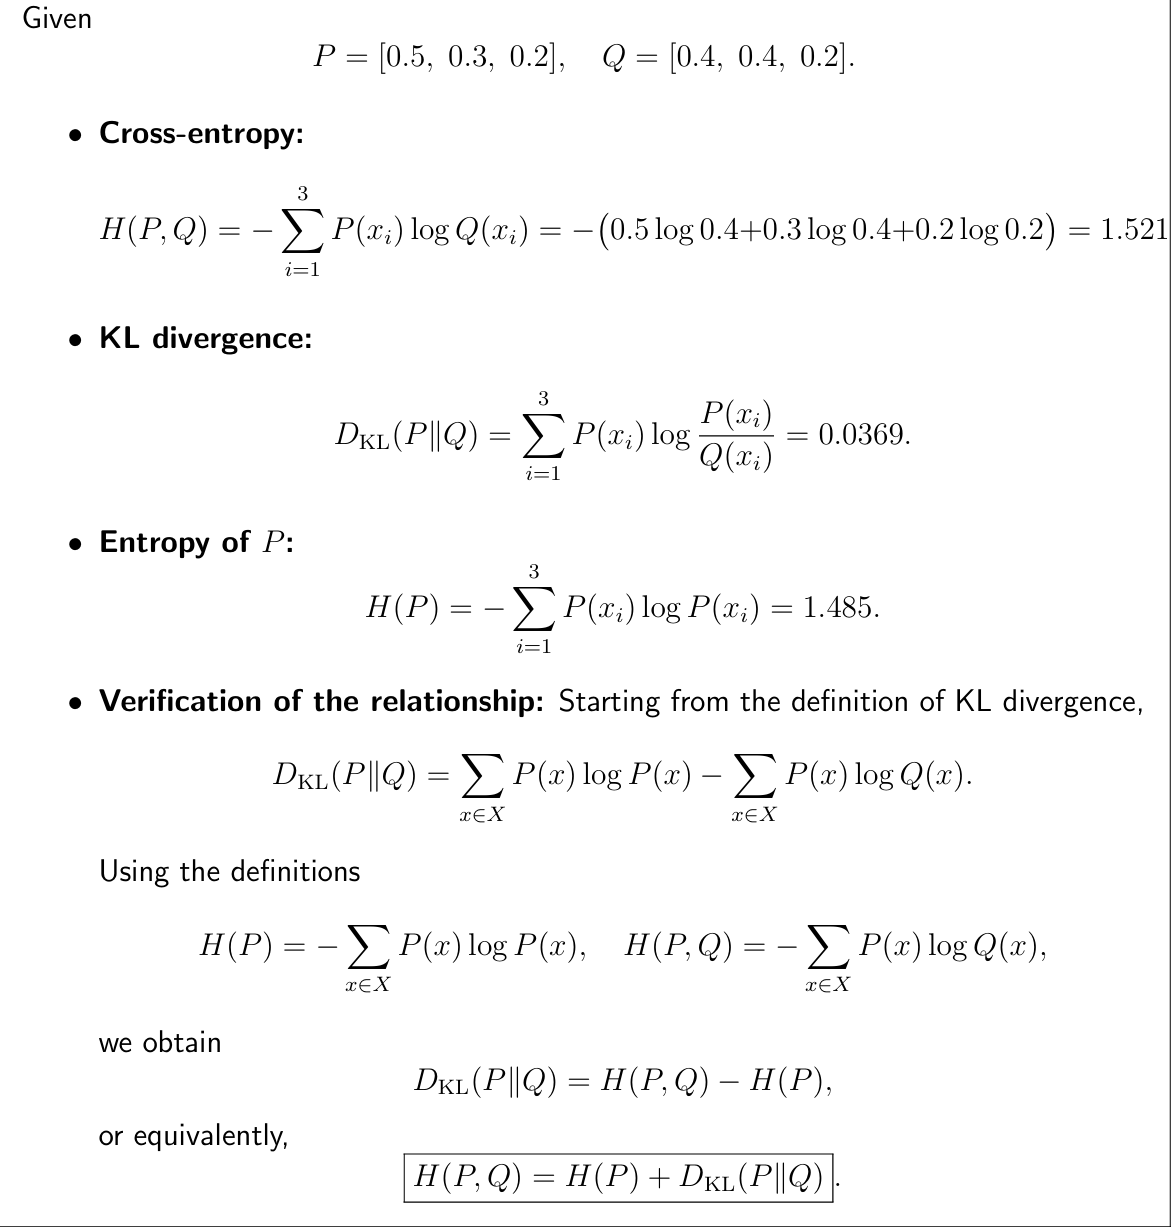

## Q3 Bias–Variance Tradeoff — Plot Matching and Justification

You are given six plots (Figure 1 A–F). Each plot represents either a classification or regression model fit to a dataset. The models differ in their complexity and decision boundaries or fitted curves.

For each plot, complete the following tasks:

Select the most appropriate bias–variance category from the options below:

- High Bias – Low Variance

- Low Bias – High Variance

- Low Bias – Low Variance

Justify your choice using concepts such as:

- Model complexity

- Underfitting vs. overfitting

- Sensitivity to noise

- Stability of the model with respect to changes in the training data








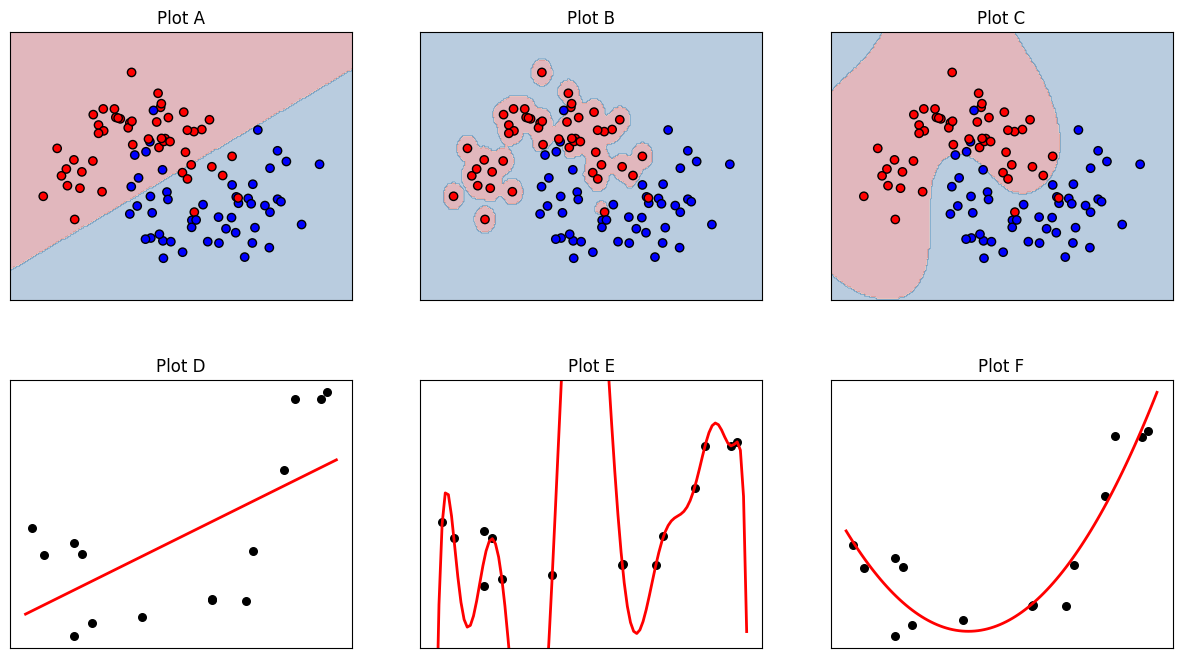

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# --- Setup Data ---
# Classification Data (Moons)
np.random.seed(42)
X_c, y_c = make_moons(n_samples=100, noise=0.25, random_state=42)

# Regression Data (Quadratic with noise)
np.random.seed(42)
X_r = np.sort(np.random.rand(15) * 5)[:, np.newaxis]
y_true_r = 0.5 * X_r**2 - 2 * X_r + 5
y_r = y_true_r + np.random.randn(15, 1) * 0.5
X_r_plot = np.linspace(0, 5, 100)[:, np.newaxis]

# --- Helper Functions ---
def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright, edgecolors='k')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

def plot_regression(ax, model, X_train, y_train, X_plot, title):
    ax.scatter(X_train, y_train, color='black', s=30, marker='o', label="Data")
    y_plot = model.predict(X_plot)
    ax.plot(X_plot, y_plot, color='red', linewidth=2, label="Model Fit")
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

# --- Generate Plot Grid ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.3)

# --- Plot A: Classification (Linear - High Bias) ---
model_a = LogisticRegression()
model_a.fit(X_c, y_c)
plot_decision_boundary(axes[0, 0], model_a, X_c, y_c, "Plot A")

# --- Plot B: Classification (Highly Nonlinear - High Variance) ---
# SVM with very high gamma creates tight islands around noise
model_b = SVC(gamma=100, C=1)
model_b.fit(X_c, y_c)
plot_decision_boundary(axes[0, 1], model_b, X_c, y_c, "Plot B")

# --- Plot C: Classification (Balanced) ---
# SVM with moderate gamma
model_c = SVC(gamma=2, C=1)
model_c.fit(X_c, y_c)
plot_decision_boundary(axes[0, 2], model_c, X_c, y_c, "Plot C")

# --- Plot D: Regression (Linear - High Bias) ---
model_d = LinearRegression()
model_d.fit(X_r, y_r)
plot_regression(axes[1, 0], model_d, X_r, y_r, X_r_plot, "Plot D")

# --- Plot E: Regression (High-Degree Poly - High Variance) ---
# Polynomial degree 14 (N-1 samples) to hit nearly every point
model_e = make_pipeline(PolynomialFeatures(degree=14), LinearRegression())
model_e.fit(X_r, y_r)
plot_regression(axes[1, 1], model_e, X_r, y_r, X_r_plot, "Plot E")
# Zoom in slightly to see oscillations better without extreme outliers
axes[1,1].set_ylim(np.min(y_r)-2, np.max(y_r)+2)


# --- Plot F: Regression (Moderate - Balanced) ---
# Quadratic fit (degree 2) matches the underlying data generation process
model_f = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_f.fit(X_r, y_r)
plot_regression(axes[1, 2], model_f, X_r, y_r, X_r_plot, "Plot F")

plt.show()

## Figure 1 Analysis
Figure 1 A: Classification (Linear)

Category: High Bias – Low Variance

Justification: The decision boundary is a single straight line, while the data distribution is clearly nonlinear. This indicates that the model is too simple to capture the true structure of the data, leading to systematic misclassification of many points on both sides of the boundary. This systematic error reflects high bias. However, the boundary is stable and smooth, meaning it would not change much if the dataset were slightly perturbed, indicating low variance.

Figure 1 B: Classification (Highly Nonlinear)

Category: Low Bias – High Variance

Justification: The decision boundary is highly irregular and forms small, tight regions around individual data points, including apparent noise points. This shows that the model is very flexible and can closely fit the training data, resulting in low bias. However, such a boundary is extremely sensitive to small changes in the data; adding or removing a few points would significantly alter the boundary. This instability is characteristic of high variance and suggests overfitting.

Figure 1 C: Classification (Moderately Nonlinear)

Category: Low Bias – Low Variance

Justification: The decision boundary is smooth and nonlinear, allowing it to capture the overall class structure without fitting noise. The model is flexible enough to represent the true decision boundary, resulting in low bias, but not so flexible that it creates unnecessary complexity. Because the boundary is smooth and not overly sensitive to individual points, the model is also stable, indicating low variance. This plot represents a good bias–variance tradeoff.

Figure 1 D: Regression (Linear)

Category: High Bias – Low Variance

Justification: The fitted model is a straight line, while the data clearly follow a nonlinear trend. This mismatch results in large and systematic residuals across the input range, indicating that the model consistently underfits the data. This is a sign of high bias. Since the linear model is very simple, its fit would not change much with different training samples, indicating low variance.

Figure 1 E: Regression (High-Degree Polynomial)

Category: Low Bias – High Variance

Justification: The regression curve is highly oscillatory and closely follows individual data points, even where the data appear noisy. This indicates a very complex model, such as a high-degree polynomial, which can approximate the training data extremely well, leading to low bias. However, the sharp fluctuations between points suggest that the model is highly sensitive to noise, and small changes in the data would produce large changes in the fitted curve. This instability reflects high variance and overfitting.

Figure 1 F: Regression (Moderate Complexity)

Category: Low Bias – Low Variance

Justification: The fitted curve is smooth and nonlinear, capturing the overall trend of the data without excessive oscillations. The model is flexible enough to represent the underlying relationship, resulting in low bias, but avoids fitting noise. Because the curve is smooth and stable, it would not change dramatically with small variations in the dataset, indicating low variance. This plot demonstrates an effective balance between bias and variance.

## Q4  Implement XOR gate using neural network


The Exclusive-OR (XOR) function is a classic example of a Boolean function that is not linearly separable and therefore cannot be implemented using a single-layer perceptron.

The XOR function takes two binary inputs $x_1, x_2 \in \{0,1\}$ and produces a binary output $y \in \{0,1\}$.

The truth table for the XOR function is given below:

|Input A 	|Input B	|Output (A ⊕ B)|
|---|---|---|
|0	|0|	0|
|0	|1	|1|
|1	|0	|1|
|1	|1	|0|

Consider a two-layer neural network (one hidden layer and one output layer) with:

- Two input neurons

- Two hidden neurons

- One output neuron

Sigmoid activation function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Predicted probabilities:
[[0.]
 [1.]
 [1.]
 [0.]]

Binary output:
[[0]
 [1]
 [1]
 [0]]


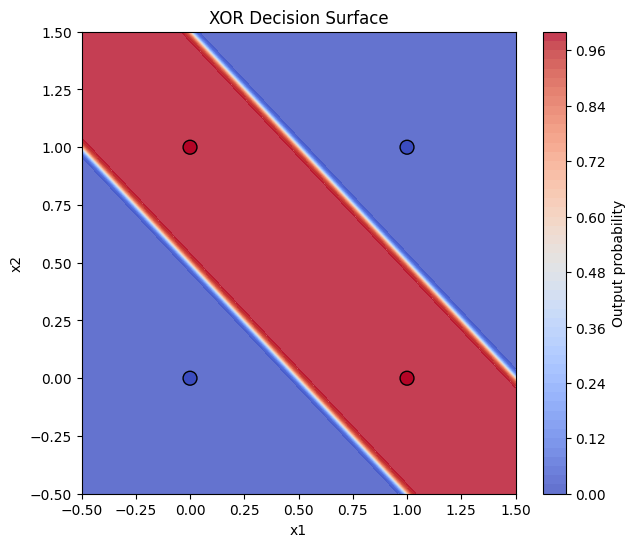

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Activation function
# ----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----------------------------
# XOR input
# ----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

# ----------------------------
# Pre-calculated weights
# ----------------------------
# Hidden layer (2 neurons)
W1 = np.array([
    [20, 20],    # weights for x1
    [20, 20]     # weights for x2
])
b1 = np.array([[-10, -30]])  # biases

# Output layer (1 neuron)
W2 = np.array([[20], [-20]])
b2 = np.array([[-10]])

# ----------------------------
# Forward pass
# ----------------------------
z1 = X @ W1 + b1
a1 = sigmoid(z1)

z2 = a1 @ W2 + b2
y_hat = sigmoid(z2)

print("Predicted probabilities:")
print(y_hat.round(4))

print("\nBinary output:")
print((y_hat > 0.5).astype(int))

# ----------------------------
# Decision surface
# ----------------------------
xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 300),
    np.linspace(-0.5, 1.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

z1_grid = grid @ W1 + b1
a1_grid = sigmoid(z1_grid)
z2_grid = a1_grid @ W2 + b2
Z = sigmoid(z2_grid).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.8)
plt.colorbar(label="Output probability")

plt.scatter(
    X[:, 0], X[:, 1],
    c=y.ravel(),
    cmap="coolwarm",
    edgecolors="k",
    s=100
)

plt.title("XOR Decision Surface")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


#Question 5

Learning Dynamics and Generalization in Neural Networks
A supervised learning model is trained using gradient-based optimization. The behavior of
training and validation losses provides insight into the learning dynamics and generalization
ability of the model.  

(a) During training, the training loss decreases steadily, but the validation loss starts increasing after a few epochs. Explain what this behavior indicates. Suggest two practical strategies to address this issue and explain why they work.   

(b) Two neural networks are trained on the same dataset:
• Network A: shallow but very wide
• Network B: deep but narrow
Both achieve similar training loss. Discuss how their generalization behavior may differ and justify your reasoning.  

(c) Explain how the choice of activation function affects gradient flow during backpropagation. Compare sigmoid and ReLU activations in deep networks without using their mathematical definitions.  

(d) Suppose all weights in a multilayer neural network are initialized to zero. Explain what happens during training and why learning fails in this case.

(e) A model achieves very low bias but performs poorly on unseen test data. Explain how
this situation can arise and discuss whether increasing the dataset size would help.

Solution:  

(a) This behavior indicates overfitting. The model continues to fit the training data
but begins to memorize noise, leading to poor generalization.
Two strategies:
• Early stopping: Training is stopped when validation loss starts increasing,
preventing the model from fitting noise.
• Regularization (L2 or dropout): These methods constrain model complex-
ity, reducing sensitivity to noise.  

(b) A shallow but wide network may rely on memorization using many parameters,
increasing overfitting risk. A deep but narrow network can learn hierarchical representations, often generalizing better due to structured feature learning, even with fewer parameters.  

(c) Sigmoid activations tend to suppress gradient flow in deep networks, making learning slow or ineffective. ReLU activations allow gradients to propagate more effectively,enabling deeper networks to train successfully, though they may suffer from inactive neurons.  

(d) When all weights are initialized to zero, all neurons in the same layer receive identical gradients and update identically. This symmetry prevents the network from learning diverse features, causing training to fail.  

(e) Low bias with poor test performance indicates high variance. The model fits
training data well but does not generalize. Increasing dataset size often helps by providing more diverse examples, reducing variance and improving generalization.

# Question 6

##Comparison of Loss Functions: Mean Squared Error vs Cross-Entropy

####Loss functions play a crucial role in training machine learning models by quantifying the discrepancy between true labels and model predictions.
##a. Definition of Loss Functions
####Define the following loss functions for a binary classification problem:

For a true label y ∈ {0, 1} and predicted probability ˆy ∈ [0, 1]:

####• Mean Squared Error (MSE):

LMSE = 1/2(y − ˆy)2

####• Binary Cross-Entropy Loss:

LCE = − [y log(ˆy) + (1 − y) log(1 − ˆy)]

##b. Behavior and Gradient Characteristics
####Compare MSE and Cross-Entropy loss in terms of:
##### Sensitivity to prediction errors
#####Gradient behavior when predictions are confident but incorrect

#### • MSE: Penalizes errors quadratically but produces small gradients when predictions are close to 0 or 1, even if the prediction is wrong. This can slow down learning.
#### • Cross-Entropy: Produces large gradients for confident but incorrect predictions, strongly penalizing misclassifications and leading to faster convergence.


##c. Suitability for Classification
####Explain why Cross-Entropy loss is generally preferred over MSE for classification tasks such as logistic regression.
####Cross-Entropy loss is preferred for classification because:
####• It is derived from maximum likelihood estimation for probabilistic models
####• It directly measures the distance between true and predicted probability distributions
####• It avoids gradient saturation issues common with MSE when used with sigmoid activation
Thus, Cross-Entropy provides more informative gradients and better optimization
behavior for classification tasks.

##d. Task-based Comparison
####Give one example where MSE is more suitable and one example where Cross-Entropy is more suitable. Justify your choices.

####• MSE is suitable for: Regression tasks such as predicting house prices or temperature, where outputs are continuous values.
####• Cross-Entropy is suitable for: Classification tasks such as spam detection or image classification, where outputs represent class probabilities.

#Question 7

##Implement Loss Functions from Scratch

In this question, you will implement basic loss functions used in machine learning using
NumPy only. Do not use any machine learning libraries.

###Mean Squared Error (MSE):
Write a Python function that computes the Mean Squared Error loss given:

• True labels y

• Predicted values ˆy
###Binary Cross-Entropy Loss:
Write a Python function that computes the Binary Cross-Entropy loss for a binary
classification task given:

• True labels y ∈ {0, 1}

• Predicted probabilities ˆy ∈ (0, 1)
###Numerical Stability:

Explain briefly why it is important to clip predicted probabilities when computing cross-entropy loss.

In [ ]:
## Mean Squared Error (MSE)
import numpy as np

def mean_squared_error(y, y_hat):
  y = np.array(y)
  y_hat = np.array(y_hat)
  return 0.5 * np.mean((y - y_hat) ** 2)

##Binary Cross-Entropy Loss

def binary_cross_entropy(y, y_hat):
  y = np.array(y)
  y_hat = np.array(y_hat)
  #Numerical stability
  epsilon = 1e-9
  y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
  loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
  return loss

##Numerical Stability :
'''
Predicted probabilities can be very close to 0 or 1, which causes log(0) and leads
to numerical instability. Clipping ensures that logarithms remain finite and prevents
undefined values during training.
'''

'\nPredicted probabilities can be very close to 0 or 1, which causes log(0) and leads\nto numerical instability. Clipping ensures that logarithms remain finite and prevents\nundefined values during training.\n'

## question 8
Logistic Regression with L2 Regularization on MNIST
In this question, you will implement binary logistic regression with L2 regularization
from scratch using only NumPy.

Use the MNIST dataset and create a binary classification task as follows:
• Class 0: Digit 0
• Class 1: Digit 1

You must:
1. Load the MNIST dataset you may use tensorflow (from tensorflow.keras.datasets
import mnist).
2. Flatten the images and normalize input features.
3. Implement logistic regression with:
• Sigmoid activation function
• Binary cross-entropy loss
• L2 regularization on weights
4. Train the model using batch gradient descent.

Report the following for both training and test sets:

• Loss vs iterations plot

• Confusion matrix

• Accuracy, Precision, Recall, and F1-score

Compare results for different regularization strengths:

λ ∈ {0, 0.01, 0.1, 1.0}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Select only digits 0 and 1
train_filter = np.where((y_train == 0) | (y_train == 1))
test_filter = np.where((y_test == 0) | (y_test == 1))

x_train, y_train = x_train[train_filter], y_train[train_filter]
x_test, y_test = x_test[test_filter], y_test[test_filter]


# Flatten images (28x28 -> 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to column vectors
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_loss(X, y, w, b, lambda_):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)

    # Avoid log(0)
    epsilon = 1e-8

    # -(y log (y^)  + (1-y)log(1-y^))
    loss = -np.mean(
        y * np.log(y_hat + epsilon) +
        (1 - y) * np.log(1 - y_hat + epsilon)
    )

    # L2 Regularization
    l2_term = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return loss + l2_term



$
\frac{\partial J}{\partial w}
=
\frac{1}{m} X^{T}( \hat{y} - y )
+
\frac{\lambda}{m} w
$


$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)} - y^{(i)})
$


In [ ]:
def train(X, y, learning_rate=0.1, iterations=1000, lambda_=0.0):
    m, n = X.shape

    # Initialize parameters
    w = np.zeros((n, 1))
    b = 0

    losses = []

    for i in range(iterations):

        z = np.dot(X, w) + b
        y_hat = sigmoid(z)

        # Gradients
        dw = (1/m) * np.dot(X.T, (y_hat - y)) + (lambda_/m) * w
        db = (1/m) * np.sum(y_hat - y)

        # Update
        w -= learning_rate * dw
        b -= learning_rate * db

        # Store loss
        loss = compute_loss(X, y, w, b, lambda_)
        losses.append(loss)

    return w, b, losses


def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= 0.5).astype(int)



In [ ]:


lambdas = [0, 0.01, 0.1, 1.0,10,100]

results = {}

for lambda_ in lambdas:
    print(f"\nTraining with lambda = {lambda_}")

    w, b, losses = train(
        x_train, y_train,
        learning_rate=0.1,
        iterations=1000,
        lambda_=lambda_
    )

    # Predictions
    y_train_pred = predict(x_train, w, b)
    y_test_pred = predict(x_test, w, b)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)

    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    results[lambda_] = {
        "losses": losses,
        "train_cm": train_cm,
        "test_cm": test_cm,
        "train_metrics": (train_acc, train_precision, train_recall, train_f1),
        "test_metrics": (test_acc, test_precision, test_recall, test_f1)
    }



Training with lambda = 0

Training with lambda = 0.01

Training with lambda = 0.1

Training with lambda = 1.0

Training with lambda = 10

Training with lambda = 100


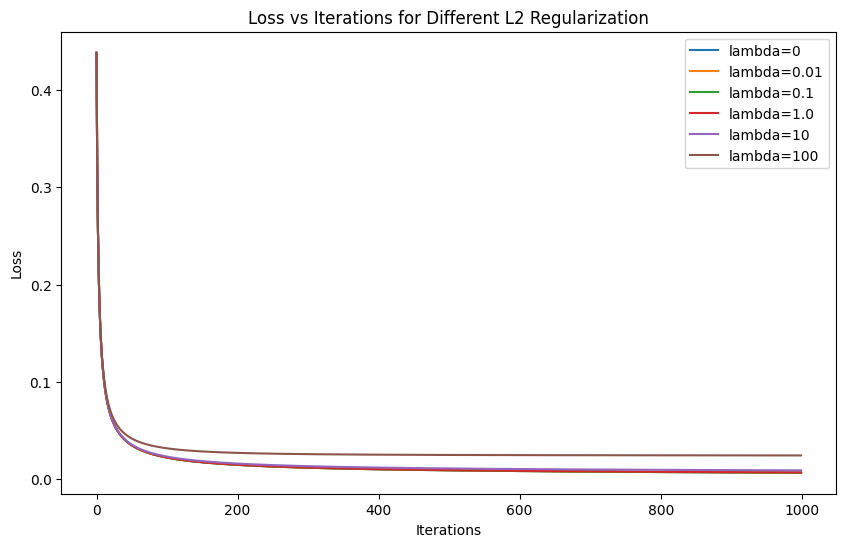

In [ ]:

plt.figure(figsize=(10,6))
for lambda_ in lambdas:
    plt.plot(results[lambda_]["losses"], label=f"lambda={lambda_}")
    # break

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations for Different L2 Regularization")
plt.legend()
plt.show()



In [ ]:
for lambda_ in lambdas:
    print("\n=================================")
    print(f"Lambda = {lambda_}")
    print("=================================")

    print("Train Confusion Matrix:\n", results[lambda_]["train_cm"])
    print("Test Confusion Matrix:\n", results[lambda_]["test_cm"])

    print("\nTrain Metrics (Acc, Prec, Recall, F1):")
    print(results[lambda_]["train_metrics"])

    print("\nTest Metrics (Acc, Prec, Recall, F1):")
    print(results[lambda_]["test_metrics"])



Lambda = 0
Train Confusion Matrix:
 [[5915    8]
 [  11 6731]]
Test Confusion Matrix:
 [[ 979    1]
 [   0 1135]]

Train Metrics (Acc, Prec, Recall, F1):
(0.998499802605606, 0.9988128802492952, 0.9983684366656779, 0.9985906090052666)

Test Metrics (Acc, Prec, Recall, F1):
(0.9995271867612293, 0.9991197183098591, 1.0, 0.9995596653456627)

Lambda = 0.01
Train Confusion Matrix:
 [[5915    8]
 [  11 6731]]
Test Confusion Matrix:
 [[ 979    1]
 [   0 1135]]

Train Metrics (Acc, Prec, Recall, F1):
(0.998499802605606, 0.9988128802492952, 0.9983684366656779, 0.9985906090052666)

Test Metrics (Acc, Prec, Recall, F1):
(0.9995271867612293, 0.9991197183098591, 1.0, 0.9995596653456627)

Lambda = 0.1
Train Confusion Matrix:
 [[5915    8]
 [  11 6731]]
Test Confusion Matrix:
 [[ 979    1]
 [   0 1135]]

Train Metrics (Acc, Prec, Recall, F1):
(0.998499802605606, 0.9988128802492952, 0.9983684366656779, 0.9985906090052666)

Test Metrics (Acc, Prec, Recall, F1):
(0.9995271867612293, 0.9991197183098591, 

## Question 9

Numerical Problem on Logistic Regression Prediction

Consider a binary logistic regression model defined as:
$
P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad
z = w^T x + b
$

Given:
$
w =
\begin{pmatrix}
0.6 \\
-0.4
\end{pmatrix},
\quad
b = -0.2,
\quad
x =
\begin{pmatrix}
2 \\
1
\end{pmatrix}
$

     1. Compute the value of z.
     2. Compute the predicted probability P(y=1 \ x).
     3. Predict the class label assuming a threshold of 0.5.


##### Solution
 Step 1: Compute $z$

$
z = w^T x + b
= (0.6)(2) + (-0.4)(1) - 0.2
$

$
z = 1.2 - 0.4 - 0.2 = 0.6
$


  Step 2: Compute predicted probability

$
P(y=1 \mid x) = \sigma(0.6) = \frac{1}{1 + e^{-0.6}}
$

$
e^{-0.6} \approx 0.5488
\Rightarrow
\sigma(0.6) \approx \frac{1}{1 + 0.5488} \approx 0.6457
$


  Step 3: Class prediction

Since
$
P(y=1 \mid x) = 0.6457 > 0.5
$

$
\boxed{\text{Predicted class } = 1}
$



## Question 10

Find the advantages of using NumPy or PyTorch over naive python iterators and
operations while working with neural networks.

In [ ]:
# @title
import math
import random
import matplotlib.pyplot as plt
import time


input_dims = [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
num_neuron = 4
BATCH_SIZE = 1

class Timer:
    def __init__(self):
        self.start_time = None
        self.elapsed = 0.0

    def start(self):
        self.start_time = time.perf_counter()

    def stop(self):
        if self.start_time is None:
            raise RuntimeError("Timer not started")
        self.elapsed = time.perf_counter() - self.start_time
        self.start_time = None
        return self.elapsed


## Python List:
The computation time increases with the input dimension. Note, that it would take hours to compute large matrix multiplication when implemented using python list.

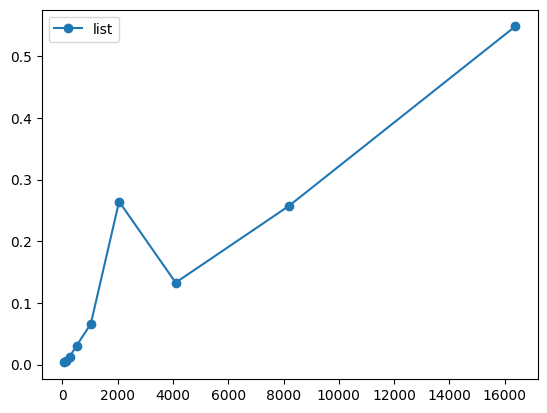

In [ ]:
# @title
def relu(x):
    return x if x > 0 else 0

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def forward_list(X, W1, b1, W2, b2):
    """
    X  : list of shape (B, d)
    W1 : list of shape (h, d)
    b1 : list of shape (h,)
    W2 : list of shape (1, h)
    b2 : list of shape (1,)
    """

    B = len(X)
    d = len(X[0])
    h = len(W1)

    outputs = []

    for n in range(B):

        # ----- Hidden Layer -----
        hidden = []
        for i in range(h):
            s = 0.0
            for j in range(d):
                s += X[n][j] * W1[i][j]
            s += b1[i]
            hidden.append(relu(s))

        # ----- Output Layer -----
        s_out = 0.0
        for i in range(h):
            s_out += hidden[i] * W2[0][i]
        s_out += b2[0]

        outputs.append([sigmoid(s_out / math.sqrt(h))])

    return outputs

def random_matrix(inp, out):
    return [[random.gauss(0, 1) for _ in range(out)] for _ in range(inp)]

def random_vector(dim):
    return [random.gauss(0, 1) for _ in range(dim)]

def get_time_list():
    t = Timer()

    time_taken = []
    for dim in input_dims:
        # t.start()
        X  = random_matrix(BATCH_SIZE, dim)
        W1 = random_matrix(num_neuron, dim)
        b1 = random_vector(num_neuron)
        W2 = random_matrix(1, num_neuron)
        b2 = random_vector(1)

        y = forward_list(X, W1, b1, W2, b2)

        t.start()

        forward_list(X, W1, b1, W2, b2)

        time_taken.append(t.stop())

    return time_taken


time_in_list = get_time_list()

plt.plot(input_dims, time_in_list, label="list", marker='o')

plt.legend()
plt.show()

## Numpy Arrays:
The computation time increases with the input dimension. Though, it is much faster than naive python lists due to vectorized compuation.

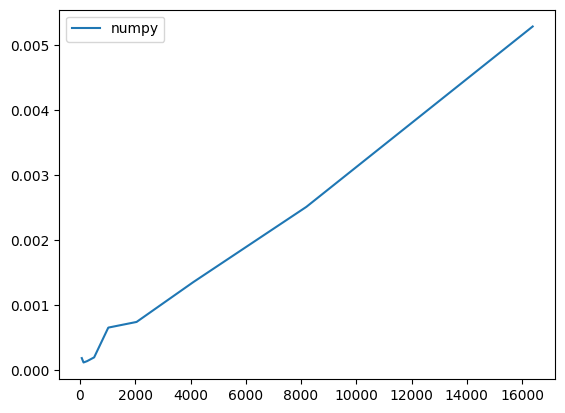

In [ ]:
# @title
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_numpy(x, W1, b1, W2, b2):
    """
    X  : numpy array of shape (B, d)
    W1 : numpy array of shape (h, d)
    b1 : numpy array of shape (h,)
    W2 : numpy array of shape (1, h)
    b2 : numpy array of shape (1,)
    """
    h = x @ W1.T + b1 ## Broadcasting is done automatically here  (B, h) + (h,)
    h = np.maximum(h, 0)
    y = h @ W2.T + b2 ## Broadcasting is done automatically here  (B, 1) + (1,)
    y = sigmoid(y / np.sqrt(h.shape[1]))
    return y


t = Timer()

# BATCH_SIZE = 512

def get_time_np():
    time_taken = []
    for dim in input_dims:
        # t.start()

        X = np.random.randn(BATCH_SIZE, dim)
        W1 = np.random.randn(num_neuron, dim)
        b1 = np.random.randn(num_neuron,)
        W2 = np.random.randn(1,num_neuron)
        b2 = np.random.randn(1)

        t.start()

        forward_numpy(X, W1, b1, W2, b2)

        time_taken.append(t.stop())

    return time_taken

time_in_numpy = get_time_np()

plt.plot(input_dims,time_in_numpy, label="numpy")

plt.legend()
plt.show()


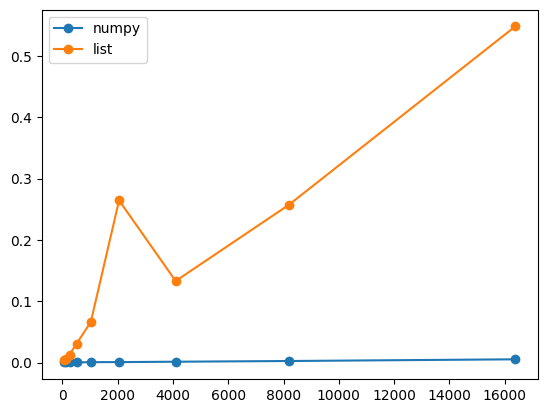

In [ ]:
plt.plot(input_dims,time_in_numpy, label="numpy", marker = 'o')

plt.plot(input_dims, time_in_list, label="list", marker='o')

plt.legend()
plt.show()


## Pytorch Tensors:
The computation time increases with the input dimension when computation is done on CPU. The computation time remains almost constant when forward pass is done on GPU, it is because of parallelization of matrix multiplation on multiple (100s) of cores that are available on GPUs.

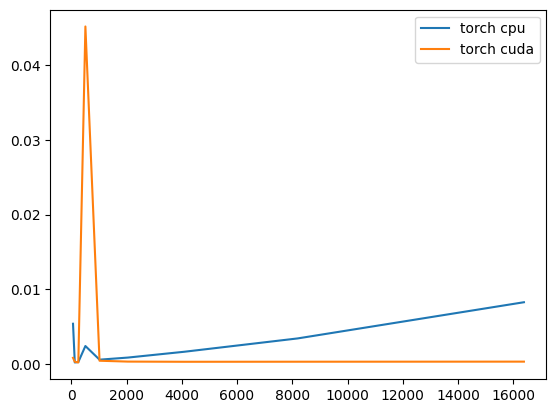

In [ ]:
# @title
import torch

@torch.no_grad()
def forward_torch(x, W1, b1, W2, b2):
    h = x @ W1.T + b1 -#> (B, h) + (1, h)
    h = torch.relu(h)
    y = h @ W2.T + b2
    return y


# example
t = Timer()

BATCH_SIZE = 512

def get_time(device = "cpu", grad = False):
    time_taken = []
    for dim in input_dims:
        # t.start()

        X = torch.randn(BATCH_SIZE, dim, device=device, requires_grad = grad)
        W1 = torch.randn(num_neuron, dim, device=device, requires_grad = grad)
        b1 = torch.randn(num_neuron, device=device, requires_grad = grad)
        W2 = torch.randn(1,num_neuron, device=device, requires_grad = grad)
        b2 = torch.randn(1, device=device, requires_grad = grad)

        t.start()

        forward_torch(X, W1, b1, W2, b2)

        time_taken.append(t.stop())

    return time_taken


time_in_torch_cuda = get_time(device = "cuda")
time_in_torch_cpu = get_time(device = "cpu")
time_in_torch_cuda_with_grad = get_time(device = "cpu", grad = True)

plt.plot(input_dims,time_in_torch_cpu, label="torch cpu")
plt.plot(input_dims,time_in_torch_cuda, label="torch cuda")
# plt.plot(time_in_torch_cuda_with_grad, label="torch cuda with grad")


plt.legend()
plt.show()


Broadcasting is the automatic expansion of dimensions of size 1 in a tensor to match another tensor’s shape during elementwise operations, enabling concise code and efficient computation without copying data.

In [ ]:
# @title
A = np.random.random((3, 4))
x = np.ones((4)) ## treated as (1, 4), ->( 3, 4)

y = np.ones((3, 1))

print("Matrix A:")
print(A)
print("\nVector x:")
print(x)
print("\nVector y:")
print(y)
print("\nResult of A + x:")
print(A + x)
print("\nResult of A + y:")
print(A + y)


print("broadcasting along more than 1 dimensions")

A = np.zeros((2, 3, 4))
b = np.ones((1, 3, 1))

C = A + b
print(C.shape)
print(C)

Matrix A:
[[0.55152245 0.0748498  0.14313779 0.27465338]
 [0.51639954 0.0387744  0.4508107  0.47804386]
 [0.15260167 0.59947865 0.34367321 0.69738076]]

Vector x:
[1. 1. 1. 1.]

Vector y:
[[1.]
 [1.]
 [1.]]

Result of A + x:
[[1.55152245 1.0748498  1.14313779 1.27465338]
 [1.51639954 1.0387744  1.4508107  1.47804386]
 [1.15260167 1.59947865 1.34367321 1.69738076]]

Result of A + y:
[[1.55152245 1.0748498  1.14313779 1.27465338]
 [1.51639954 1.0387744  1.4508107  1.47804386]
 [1.15260167 1.59947865 1.34367321 1.69738076]]
broadcasting along more than 1 dimensions
(2, 3, 4)
[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]


## Question 11
Prove that the Logistic Regression Loss Function is Convex

Consider a binary classification problem with labels $y \in \{0,1\}$.

Logistic regression models the conditional probability as

$$
P(y = 1 \mid x; w) = \sigma(w^\top x),
\quad
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The empirical loss function is given by

$$
L(w) = \sum_{i=1}^n \left[
- y_i \log \sigma(w^\top x_i)
- (1 - y_i)\log\big(1 - \sigma(w^\top x_i)\big)
\right].
$$

Prove that $L(w)$ is a convex function of the model parameters $w$.

### 1. Logistic Regression Setup

Given a dataset $\{(x_i, y_i)\}_{i=1}^n$, where

$$
x_i \in \mathbb{R}^d, \qquad y_i \in \{0,1\},
$$

define

$$
z_i = w^\top x_i.
$$

The logistic (sigmoid) function is

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The negative log-likelihood loss for a single sample is

$$
\ell_i(w) =
- \Big[
y_i \log \sigma(z_i)
+ (1 - y_i)\log(1 - \sigma(z_i))
\Big].
$$

The empirical loss over the dataset is

$$
L(w) = \sum_{i=1}^n \ell_i(w).
$$

---

### 2. Convexity Criterion

A twice-differentiable function is convex **iff** its Hessian matrix is positive semidefinite (PSD) everywhere:

$$
\nabla^2 L(w) \succeq 0 \quad \forall\, w.
$$

Thus, we compute the Hessian of $L(w)$.

---

### 3. Gradient of the Loss

Using the identity

$$
\frac{d}{dz}\sigma(z) = \sigma(z)(1 - \sigma(z)),
$$

the gradient of the empirical loss is

$$
\nabla L(w) = \sum_{i=1}^n (\sigma(z_i) - y_i)\,x_i.
$$

---

### 4. Hessian of the Loss

Taking the second derivative, we obtain

$$
\nabla^2 L(w)
= \sum_{i=1}^n \sigma(z_i)(1 - \sigma(z_i))\,x_i x_i^\top.
$$

Each term is an outer product scaled by a non-negative scalar.

---

### 5. Positive Semidefiniteness of the Hessian

For any vector $v \in \mathbb{R}^d$, consider

$$
v^\top \nabla^2 L(w)\, v
= \sum_{i=1}^n \sigma(z_i)(1 - \sigma(z_i))\, v^\top x_i x_i^\top v.
$$

This simplifies to

$$
v^\top \nabla^2 L(w)\, v
= \sum_{i=1}^n \sigma(z_i)(1 - \sigma(z_i)) (x_i^\top v)^2.
$$

Since

$$
\sigma(z_i)(1 - \sigma(z_i)) \ge 0
\quad \text{and} \quad
(x_i^\top v)^2 \ge 0,
$$

it follows that

$$
v^\top \nabla^2 L(w)\, v \ge 0 \quad \forall\, v.
$$

Therefore,

$$
\nabla^2 L(w) \succeq 0 \quad \forall\, w.
$$

---

### 6. Conclusion

Since the Hessian of $L(w)$ is positive semidefinite for all $w$, the logistic regression loss function is **convex**.

Therefore, logistic regression is convex because it is a linear model whose likelihood belongs to the exponential family, and the associated log-partition function is convex.
